# Phase 5 — Real Image Processing

## Objective

The goal of this phase is to prepare the face recognition pipeline for real-world photographs.

The system should be able to:

- Accept a real input photograph
- Detect one or more faces
- Handle different face conditions
- Extract the detected face region
- Generate an ArcFace face embedding
- Prepare the image for one-to-many missing-person search

In this phase, different face detection approaches will be evaluated before selecting the detector for the final application.

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from deepface import DeepFace

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load input photograph

IMAGE_PATH = "photo1.jpg"

image = cv2.imread(IMAGE_PATH)

if image is None:
    raise FileNotFoundError(f"Could not load image: {IMAGE_PATH}")

print("Image loaded successfully!")
print("Image shape:", image.shape)

Image loaded successfully!
Image shape: (413, 413, 3)


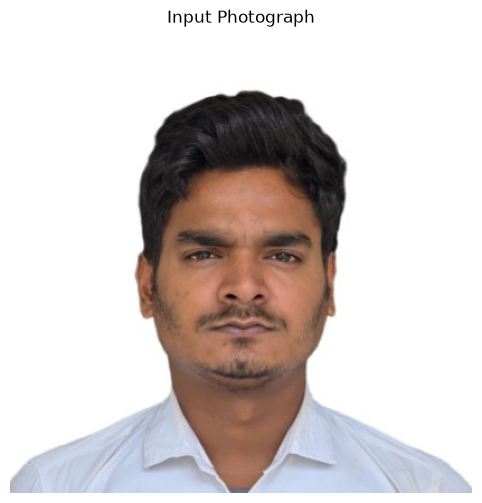

In [3]:
# Display input photograph

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Input Photograph")
plt.show()

In [4]:
# Test MTCNN face detection

detections = DeepFace.extract_faces(
    img_path=image,
    detector_backend="mtcnn",
    enforce_detection=False,
    align=True
)

print("Number of detected faces:", len(detections))

for i, face in enumerate(detections):
    print(f"Face {i + 1}:")
    print("  Confidence:", face["confidence"])
    print("  Face shape:", face["face"].shape)

Number of detected faces: 1
Face 1:
  Confidence: 1.0
  Face shape: (194, 150, 3)


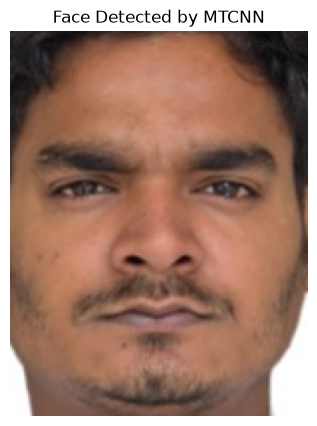

In [5]:
# Visualize the face detected by MTCNN

detected_face = detections[0]["face"]

plt.figure(figsize=(5, 5))
plt.imshow(detected_face)
plt.axis("off")
plt.title("Face Detected by MTCNN")
plt.show()

In [6]:
# Generate ArcFace embedding from the MTCNN-detected face

embedding_result = DeepFace.represent(
    img_path=detected_face,
    model_name="ArcFace",
    detector_backend="skip",
    enforce_detection=False
)

embedding = np.array(embedding_result[0]["embedding"])

print("Embedding generated successfully!")
print("Embedding shape:", embedding.shape)

Embedding generated successfully!
Embedding shape: (512,)


## Comparing Face Detectors

The current prototype used OpenCV Haar Cascade for face detection.

In this phase, MTCNN is being evaluated as an alternative face detector.

The goal is to compare the quality of the detected face regions before selecting
the detector for the final Missing Person Finder pipeline.

In [7]:
# Test OpenCV Haar Cascade face detection

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

faces = cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Number of detected faces:", len(faces))

for i, (x, y, w, h) in enumerate(faces):
    print(f"Face {i + 1}:")
    print("  Position:", (x, y))
    print("  Size:", (w, h))

Number of detected faces: 1
Face 1:
  Position: (np.int32(114), np.int32(125))
  Size: (np.int32(190), np.int32(190))


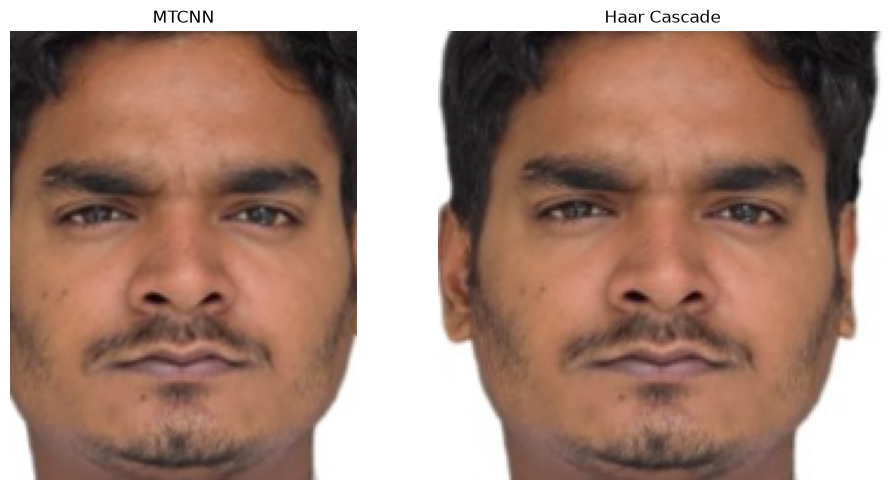

In [8]:
# Compare MTCNN and Haar Cascade face regions

x, y, w, h = faces[0]

haar_face = image_rgb[y:y+h, x:x+w]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(detected_face)
plt.axis("off")
plt.title("MTCNN")

plt.subplot(1, 2, 2)
plt.imshow(haar_face)
plt.axis("off")
plt.title("Haar Cascade")

plt.tight_layout()
plt.show()

## MTCNN Detection Test on Multiple Images

A face detector should not be selected based on a single image.

We will test MTCNN on multiple photographs and check whether it can
consistently detect the expected face regions.

In [9]:
# Test MTCNN on multiple photographs

test_images = [
    "deepface_repo/tests/unit/dataset/img1.jpg",
    "deepface_repo/tests/unit/dataset/img3.jpg",
    "deepface_repo/tests/unit/dataset/img13.jpg",
    "deepface_repo/tests/unit/dataset/img16.jpg",
    "deepface_repo/tests/unit/dataset/img18.jpg",
    "deepface_repo/tests/unit/dataset/img20.jpg",
    "deepface_repo/tests/unit/dataset/img22.jpg",
    "deepface_repo/tests/unit/dataset/img24.jpg"
]

for image_path in test_images:
    detections = DeepFace.extract_faces(
        img_path=image_path,
        detector_backend="mtcnn",
        enforce_detection=False,
        align=True
    )

    print(
        os.path.basename(image_path),
        "→",
        len(detections),
        "face(s)"
    )

img1.jpg → 1 face(s)
img3.jpg → 1 face(s)
img13.jpg → 1 face(s)
img16.jpg → 1 face(s)
img18.jpg → 1 face(s)
img20.jpg → 1 face(s)
img22.jpg → 1 face(s)
img24.jpg → 1 face(s)


## MTCNN Detection Results

MTCNN was tested on 8 photographs from the evaluation dataset.

### Results

- Images tested: 8
- Images with exactly one detected face: 8
- Images with no detected face: 0
- Images with multiple detected faces: 0
- Detection success rate: 100%

### Observation

MTCNN successfully detected exactly one face in all 8 tested photographs.

This provides an initial indication that MTCNN is suitable for the current
prototype images. However, this result is based on a small and controlled
sample and should not be interpreted as real-world detection accuracy.

Further testing with varied real-world photographs is required before
finalizing the face detector.

In [11]:
# Cosine distance function

def cosine_distance(embedding_a, embedding_b):
    similarity = np.dot(embedding_a, embedding_b) / (
        np.linalg.norm(embedding_a) * np.linalg.norm(embedding_b)
    )

    distance = 1 - similarity

    return distance

print("Cosine distance function ready!")

Cosine distance function ready!


In [12]:
# Test the complete MTCNN + ArcFace search pipeline

# Load stored face embeddings
saved_data = np.load("face_embeddings.npz")

stored_embeddings = saved_data["embeddings"]
stored_metadata = saved_data["metadata"]

# Detect face using MTCNN
query_path = "deepface_repo/tests/unit/dataset/img1.jpg"

mtcnn_faces = DeepFace.extract_faces(
    img_path=query_path,
    detector_backend="mtcnn",
    enforce_detection=True,
    align=True
)

query_face = mtcnn_faces[0]["face"]

# Generate ArcFace embedding from the MTCNN face crop
result = DeepFace.represent(
    img_path=query_face,
    model_name="ArcFace",
    detector_backend="skip",
    enforce_detection=False
)

query_embedding = np.array(result[0]["embedding"])

print("Query embedding shape:", query_embedding.shape)

# Calculate distances against stored embeddings
search_results = []

for i, stored_embedding in enumerate(stored_embeddings):

    distance = cosine_distance(
        query_embedding,
        stored_embedding
    )

    search_results.append({
        "person": stored_metadata[i][0],
        "image": stored_metadata[i][1],
        "distance": distance
    })

# Rank by smallest distance
search_results = sorted(
    search_results,
    key=lambda x: x["distance"]
)

print("\nTop 5 matches:")

for result in search_results[:5]:
    print(
        result["person"],
        result["image"],
        "distance:",
        round(result["distance"], 4)
    )

Query embedding shape: (512,)

Top 5 matches:
person1 img5.jpg distance: 0.5624
person1 img4.jpg distance: 0.593
person1 img7.jpg distance: 0.5941
person1 img2.jpg distance: 0.5975
person1 img11.jpg distance: 0.6292


In [13]:
# Evaluate MTCNN + ArcFace search on all 8 identities

test_queries = [
    ("person1", "img1.jpg"),
    ("person2", "img3.jpg"),
    ("person3", "img13.jpg"),
    ("person4", "img16.jpg"),
    ("person5", "img18.jpg"),
    ("person6", "img20.jpg"),
    ("person7", "img22.jpg"),
    ("person8", "img24.jpg")
]

dataset_dir = "deepface_repo/tests/unit/dataset"

for expected_person, image_name in test_queries:

    query_path = os.path.join(dataset_dir, image_name)

    # Detect face using MTCNN
    mtcnn_faces = DeepFace.extract_faces(
        img_path=query_path,
        detector_backend="mtcnn",
        enforce_detection=True,
        align=True
    )

    query_face = mtcnn_faces[0]["face"]

    # Generate ArcFace embedding
    result = DeepFace.represent(
        img_path=query_face,
        model_name="ArcFace",
        detector_backend="skip",
        enforce_detection=False
    )

    query_embedding = np.array(result[0]["embedding"])

    # Search stored embeddings
    search_results = []

    for i, stored_embedding in enumerate(stored_embeddings):

        # Exclude the query image itself
        if stored_metadata[i][1] == image_name:
            continue

        distance = cosine_distance(
            query_embedding,
            stored_embedding
        )

        search_results.append({
            "person": stored_metadata[i][0],
            "image": stored_metadata[i][1],
            "distance": distance
        })

    # Rank by smallest distance
    search_results.sort(key=lambda x: x["distance"])

    top_match = search_results[0]

    correct = top_match["person"] == expected_person

    print(
        f"{image_name} | Expected: {expected_person} | "
        f"Predicted: {top_match['person']} | "
        f"Distance: {top_match['distance']:.4f} | "
        f"Correct: {correct}"
    )

img1.jpg | Expected: person1 | Predicted: person1 | Distance: 0.5624 | Correct: True
img3.jpg | Expected: person2 | Predicted: person2 | Distance: 0.5680 | Correct: True
img13.jpg | Expected: person3 | Predicted: person3 | Distance: 0.2463 | Correct: True
img16.jpg | Expected: person4 | Predicted: person4 | Distance: 0.2689 | Correct: True
img18.jpg | Expected: person5 | Predicted: person5 | Distance: 0.1892 | Correct: True
img20.jpg | Expected: person6 | Predicted: person6 | Distance: 0.3305 | Correct: True
img22.jpg | Expected: person7 | Predicted: person7 | Distance: 0.4230 | Correct: True
img24.jpg | Expected: person8 | Predicted: person8 | Distance: 0.4694 | Correct: True


## MTCNN + ArcFace Evaluation

The complete MTCNN-based face search pipeline was evaluated using 8 held-out
queries representing 8 different identities.

### Results

- Queries tested: 8
- Correct Top-1 predictions: 8
- Incorrect Top-1 predictions: 0
- Top-1 accuracy: 100%

All 8 queries were correctly ranked with the expected identity as the
Top-1 result.

The largest correct-match cosine distance was 0.5680, which remained below
the prototype threshold of 0.68.

### Observation

MTCNN successfully detected one face in all 8 test photographs, and the
complete MTCNN → ArcFace → one-to-many search pipeline correctly identified
all 8 evaluation queries.

However, these results are based on a small controlled evaluation set and
should not be interpreted as real-world recognition accuracy.

Further comparison with the existing Haar Cascade pipeline is required
before selecting the final face detector.

In [16]:
import pandas as pd

print("Pandas imported successfully!")

Pandas imported successfully!


In [17]:
# Compare Haar Cascade and MTCNN

comparison_results = []

for expected_person, image_name in test_queries:

    query_path = os.path.join(dataset_dir, image_name)

    # --------------------------------------------------
    # 1. Haar Cascade
    # --------------------------------------------------

    original_image = cv2.imread(query_path)
    gray = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

    faces = cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(faces) > 0:

        x, y, w, h = faces[0]
        haar_face = original_image[y:y+h, x:x+w]

        haar_result = DeepFace.represent(
            img_path=haar_face,
            model_name="ArcFace",
            detector_backend="skip",
            enforce_detection=False
        )

        haar_embedding = np.array(
            haar_result[0]["embedding"]
        )

        haar_search = []

        for i, stored_embedding in enumerate(stored_embeddings):

            if stored_metadata[i][1] == image_name:
                continue

            distance = cosine_distance(
                haar_embedding,
                stored_embedding
            )

            haar_search.append(
                (stored_metadata[i][0], distance)
            )

        haar_search.sort(key=lambda x: x[1])

        haar_person = haar_search[0][0]
        haar_distance = haar_search[0][1]

    else:
        haar_person = "No face"
        haar_distance = None


    # --------------------------------------------------
    # 2. MTCNN
    # --------------------------------------------------

    mtcnn_faces = DeepFace.extract_faces(
        img_path=query_path,
        detector_backend="mtcnn",
        enforce_detection=True,
        align=True
    )

    mtcnn_face = mtcnn_faces[0]["face"]

    mtcnn_result = DeepFace.represent(
        img_path=mtcnn_face,
        model_name="ArcFace",
        detector_backend="skip",
        enforce_detection=False
    )

    mtcnn_embedding = np.array(
        mtcnn_result[0]["embedding"]
    )

    mtcnn_search = []

    for i, stored_embedding in enumerate(stored_embeddings):

        if stored_metadata[i][1] == image_name:
            continue

        distance = cosine_distance(
            mtcnn_embedding,
            stored_embedding
        )

        mtcnn_search.append(
            (stored_metadata[i][0], distance)
        )

    mtcnn_search.sort(key=lambda x: x[1])

    mtcnn_person = mtcnn_search[0][0]
    mtcnn_distance = mtcnn_search[0][1]


    # Store result
    comparison_results.append({
        "query": image_name,
        "expected": expected_person,
        "haar_prediction": haar_person,
        "haar_distance": haar_distance,
        "mtcnn_prediction": mtcnn_person,
        "mtcnn_distance": mtcnn_distance
    })


# Display results
comparison_df = pd.DataFrame(comparison_results)

comparison_df

,query,expected,haar_prediction,haar_distance,mtcnn_prediction,mtcnn_distance
0,img1.jpg,person1,person1,0.490082,person1,0.562369
1,img3.jpg,person2,person2,0.654518,person2,0.567986
2,img13.jpg,person3,person3,0.244870,person3,0.246294
3,img16.jpg,person4,person4,0.241889,person4,0.268853
4,img18.jpg,person5,person5,0.222858,person5,0.189202
5,img20.jpg,person6,person3,0.926004,person6,0.330500
6,img22.jpg,person7,person3,0.917115,person7,0.423014
7,img24.jpg,person8,person8,0.506010,person8,0.469393


In [18]:
# Calculate detector comparison metrics

haar_correct = (
    comparison_df["haar_prediction"]
    == comparison_df["expected"]
).sum()

mtcnn_correct = (
    comparison_df["mtcnn_prediction"]
    == comparison_df["expected"]
).sum()

total_queries = len(comparison_df)

haar_accuracy = haar_correct / total_queries * 100
mtcnn_accuracy = mtcnn_correct / total_queries * 100

print("Detector Comparison")
print("--------------------")

print(
    f"Haar Cascade: {haar_correct}/{total_queries} "
    f"correct ({haar_accuracy:.2f}%)"
)

print(
    f"MTCNN:        {mtcnn_correct}/{total_queries} "
    f"correct ({mtcnn_accuracy:.2f}%)"
)

Detector Comparison
--------------------
Haar Cascade: 6/8 correct (75.00%)
MTCNN:        8/8 correct (100.00%)


## Face Detector Comparison

The existing Haar Cascade detector was compared with MTCNN using the same
8 held-out query images and the same ArcFace recognition pipeline.

### Results

| Detector | Correct Predictions | Top-1 Accuracy |
|---|---:|---:|
| Haar Cascade | 6 / 8 | 75.00% |
| MTCNN | 8 / 8 | 100.00% |

### Observation

Both detectors successfully detected faces in the tested photographs.
However, the recognition results differed after the detected face regions
were passed to ArcFace.

Haar Cascade correctly identified 6 out of 8 queries, while MTCNN correctly
identified all 8 queries.

### Decision

Based on this controlled experiment, **MTCNN is selected as the face detector
for the next stage of the prototype**.

This result should not be interpreted as general or real-world accuracy because
the evaluation contains only 8 controlled queries. Further testing with
real-world photographs and more varied conditions is required.

The ArcFace model remains responsible for generating the 512-dimensional face
embeddings and performing face representation.